<a href="https://colab.research.google.com/github/SammyGbabs/Group_9-Sentiment_Analysis/blob/main/Financial_Sentiment_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **ABOUT THE DATASET**

The financial sentences with sentiment labels of two datasets (FiQA, Financial PhraseBank) combined into one easy-to-use CSV file.

## **Citations:**
Malo, Pekka, et al. "Good debt or bad debt: Detecting semantic orientations in economic texts." Journal of the Association for Information Science and Technology 65.4 (2014): 782-796.

**Link to Dataset:** https://www.kaggle.com/datasets/sbhatti/financial-sentiment-analysis

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/

In [ ]:
!kaggle datasets download sbhatti/financial-sentiment-analysis

Dataset URL: https://www.kaggle.com/datasets/sbhatti/financial-sentiment-analysis
License(s): CC0-1.0
  0% 0.00/276k [00:00<?, ?B/s]
100% 276k/276k [00:00<00:00, 53.5MB/s]


In [ ]:
import zipfile
zip_ref = zipfile.ZipFile('/content/financial-sentiment-analysis.zip', 'r')
zip_ref.extractall('/content')
zip_ref.close()

In [ ]:
#Importing necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import re
import string
import nltk
from nltk.probability import FreqDist
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.model_selection import GridSearchCV
import tensorflow as tf
import tensorflow_hub as hub
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.utils import to_categorical
from keras.regularizers import l1, l2
from tensorflow.keras.optimizers import Adam

In [ ]:
# Load the datasets
data = pd.read_csv('/content/data.csv')

In [ ]:
# Inspecting the first few rows of the dataset to understand its structure.
print("Training Data Overview:")
data.head()

Training Data Overview:


,Sentence,Sentiment
0,The GeoSolutions technology will leverage Bene...,positive
1,"$ESI on lows, down $1.50 to $2.50 BK a real po...",negative
2,"For the last quarter of 2010 , Componenta 's n...",positive
3,According to the Finnish-Russian Chamber of Co...,neutral
4,The Swedish buyout firm has sold its remaining...,neutral


In [ ]:
data.columns

Index(['Sentence', 'Sentiment'], dtype='object')

# **STATISTICAL ANALYSIS**

In [ ]:
#Statistics of Dataset
data.describe()

,Sentence,Sentiment
count,5842,5842
unique,5322,3
top,Managing Director 's comments : `` Net sales f...,neutral
freq,2,3130


In [ ]:
#Identifying Mising Value
data.isnull().sum()

,0
Sentence,0
Sentiment,0


In [ ]:
#Skewness & Kurtosis
# Convert 'Sentiment' to numerical representation
sentiment_mapping = {'negative': -1, 'neutral': 0, 'positive': 1}
data['Sentiment_Numeric'] = data['Sentiment'].map(sentiment_mapping)

# Now calculate skewness and kurtosis on the numerical column
print("Skewness:", data['Sentiment_Numeric'].skew())
print("Kurtosis:", data['Sentiment_Numeric'].kurt())

Skewness: -0.19805950885835374
Kurtosis: -0.7486337852273075


In [ ]:
#Percentile Analysis (Outliers Detection)
data['Sentiment_Numeric'].quantile([0.01, 0.25, 0.5, 0.75, 0.99])

,Sentiment_Numeric
0.01,-1.0
0.25,0.0
0.50,0.0
0.75,1.0
0.99,1.0


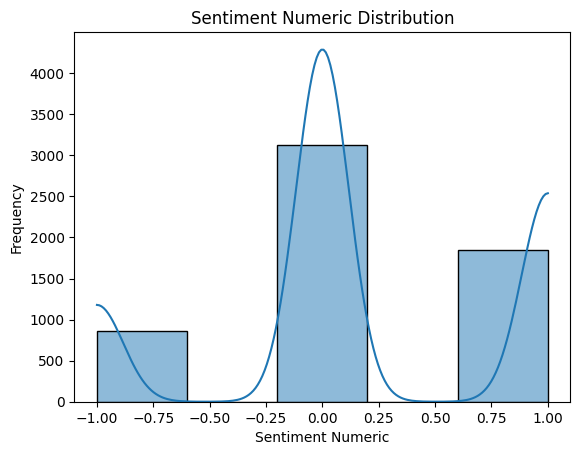

In [ ]:
#Bar chart for Sentiment Numeric Distribution
sns.histplot(data['Sentiment_Numeric'], bins=5, kde=True)
plt.title('Sentiment Numeric Distribution')
plt.xlabel('Sentiment Numeric')
plt.ylabel('Frequency')
plt.show()

<ipython-input-13-c8b088ad0a1f>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data, x='Sentiment', palette='viridis')


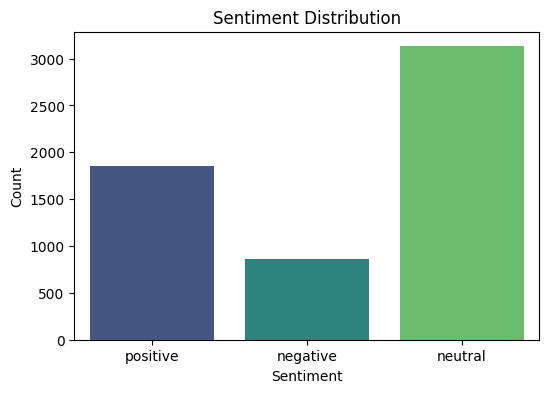

In [ ]:
# Bar chart of the Count of each sentiment
plt.figure(figsize=(6, 4))
sns.countplot(data=data, x='Sentiment', palette='viridis')
plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()


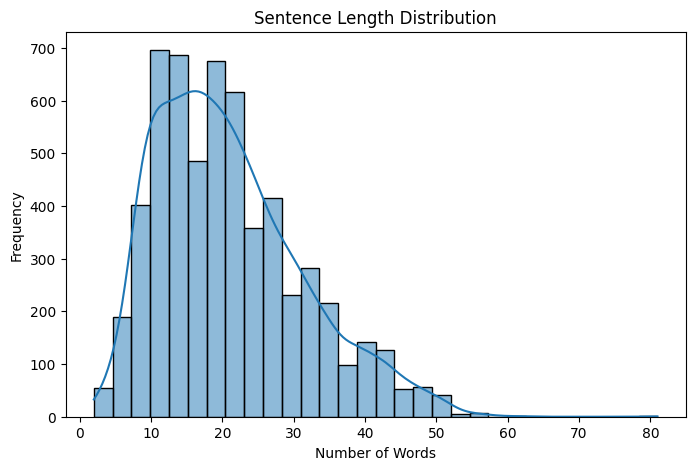

In [ ]:
#Histogram of the Sentence length Distribution
data["sentence_length"] = data["Sentence"].apply(lambda x: len(x.split()))
plt.figure(figsize=(8, 5))
sns.histplot(data["sentence_length"], bins=30, kde=True)
plt.title("Sentence Length Distribution")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()


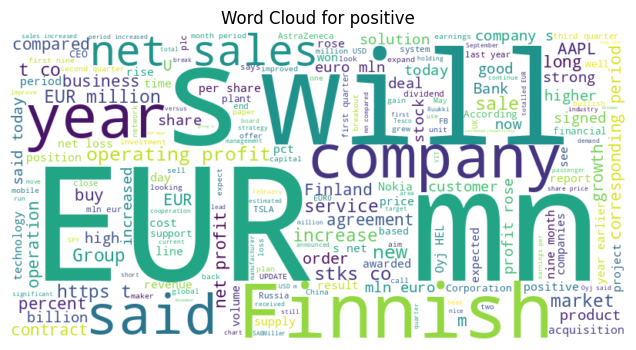

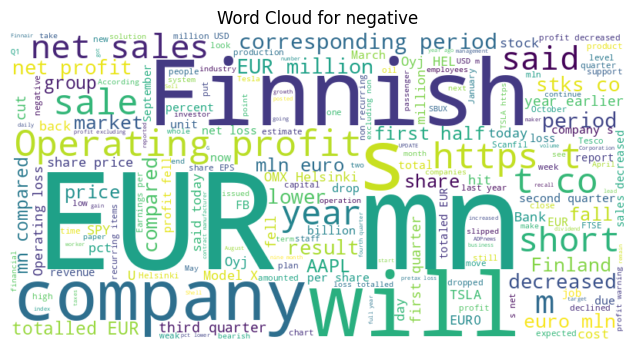

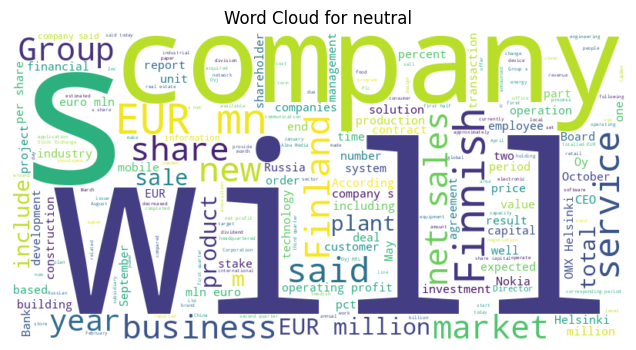

In [ ]:
#Word cloud for Each Sentiment
def generate_wordcloud(sentiment):
    text = " ".join(data[data["Sentiment"] == sentiment]["Sentence"])
    wordcloud = WordCloud(width=800, height=400, background_color="white").generate(text)

    plt.figure(figsize=(8, 4))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Word Cloud for {sentiment}")
    plt.show()

# Generate word clouds for each sentiment
for sentiment in data["Sentiment"].unique():
    generate_wordcloud(sentiment)

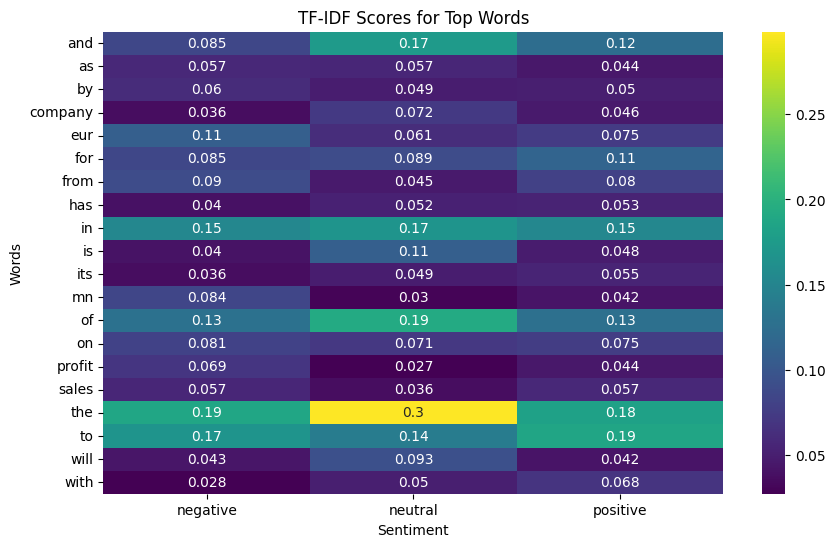

In [ ]:
# Convert text to TF-IDF features
vectorizer = TfidfVectorizer(max_features=20)
# Changed 'text' to 'Sentence' to access the correct column
X = vectorizer.fit_transform(data["Sentence"])

# Create DataFrame
tfidf_df = pd.DataFrame(X.toarray(), columns=vectorizer.get_feature_names_out())
tfidf_df["Sentiment"] = data["Sentiment"]

# Compute mean TF-IDF per sentiment
tfidf_mean = tfidf_df.groupby("Sentiment").mean() # Changed 'sentiment' to 'Sentiment' for consistency

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(tfidf_mean.T, cmap="viridis", annot=True)
plt.title("TF-IDF Scores for Top Words")
plt.xlabel("Sentiment")
plt.ylabel("Words")
plt.show()

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
<ipython-input-17-1b2a59a89c69>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="viridis")


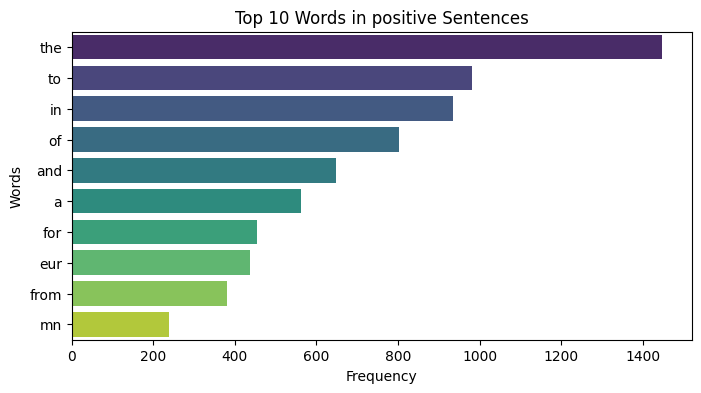

<ipython-input-17-1b2a59a89c69>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="viridis")


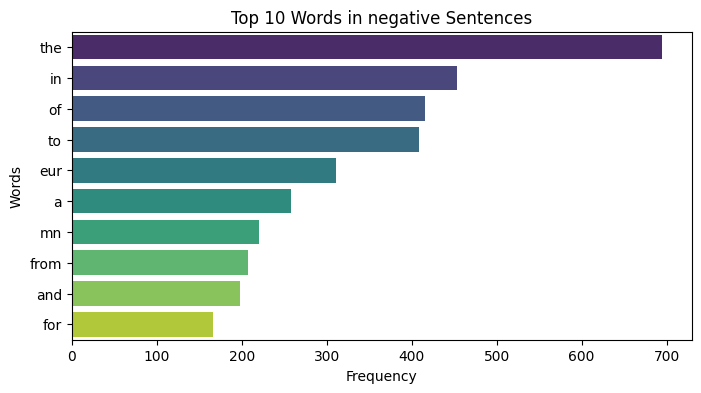

<ipython-input-17-1b2a59a89c69>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(words), palette="viridis")


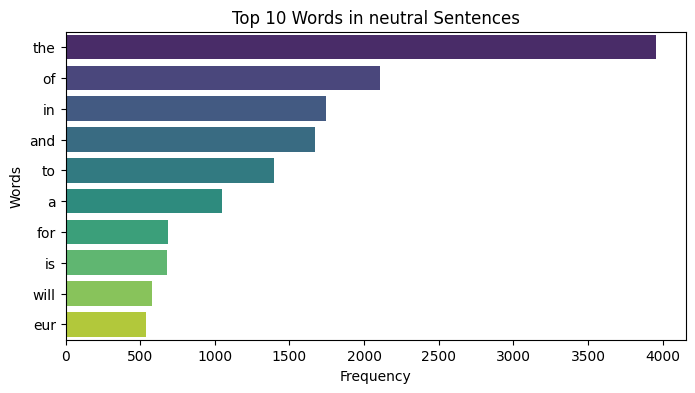

In [ ]:
# Download the 'punkt' and 'punkt_tab' resources
nltk.download('punkt')
nltk.download('punkt_tab')

def plot_word_frequency(sentiment, n=10):
    text = " ".join(data[data["Sentiment"] == sentiment]["Sentence"])
    words = [word.lower() for word in word_tokenize(text) if word.isalpha()]
    freq_dist = FreqDist(words)
    common_words = freq_dist.most_common(n)

    words, counts = zip(*common_words)

    plt.figure(figsize=(8, 4))
    sns.barplot(x=list(counts), y=list(words), palette="viridis")
    plt.xlabel("Frequency")
    plt.ylabel("Words")
    plt.title(f"Top {n} Words in {sentiment} Sentences")
    plt.show()

# Generate bar charts for each sentiment
for sentiment in data["Sentiment"].unique():
    plot_word_frequency(sentiment)

# **Data Preprocessing**

In [ ]:
# Download required NLTK resources
nltk.download('stopwords')
nltk.download('punkt')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:
# Initialize the lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

In [ ]:
# Text Cleaning Function
def clean_text(text):
    text = text.lower()  # Convert to lowercase
    text = re.sub(r'\d+', '', text)  # Remove numbers
    text = re.sub(r'\W+', ' ', text)  # Remove special characters and punctuation
    tokens = word_tokenize(text)  # Tokenize text
    tokens = [word for word in tokens if word not in stop_words]  # Remove stopwords
    tokens = [lemmatizer.lemmatize(word) for word in tokens]  # Lemmatization
    return ' '.join(tokens)

In [ ]:
# Apply text preprocessing to the "Sentence" column
data["Cleaned_Sentence"] = data["Sentence"].astype(str).apply(clean_text)

In [ ]:
# Handling missing values
data.dropna(inplace=True)

In [ ]:
# Splitting the dataset into 70% train and 30% temp (to be further split into test and validation)
X_train, X_temp, y_train, y_temp = train_test_split(
    data['Cleaned_Sentence'], data['Sentiment'], test_size=0.3, stratify=data['Sentiment'], random_state=42
)

# Splitting temp dataset into 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42
)

In [ ]:
# Display sample cleaned text
print("Sample Cleaned Sentence:", data['Cleaned_Sentence'].iloc[0])


Sample Cleaned Sentence: geosolutions technology leverage benefon gps solution providing location based search technology community platform location relevant multimedia content new powerful commercial model


In [ ]:
# Display dataset shape after splitting
print("Training Data Shape:", X_train.shape)
print("Validation Data Shape:", X_val.shape)
print("Testing Data Shape:", X_test.shape)

Training Data Shape: (4089,)
Validation Data Shape: (876,)
Testing Data Shape: (877,)


In [ ]:
# Vectorization using TF-IDF
tfidf_vectorizer = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_val_tfidf = tfidf_vectorizer.transform(X_val)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

In [ ]:
# BERT Embeddings (using Universal Sentence Encoder)
bert_model = hub.load("https://tfhub.dev/google/universal-sentence-encoder/4")

def embed_text(sentences):
    return np.array(bert_model(sentences))

X_train_bert = embed_text(X_train.tolist())
X_val_bert = embed_text(X_val.tolist())
X_test_bert = embed_text(X_test.tolist())

In [ ]:
# Print shapes of transformed data
print("TF-IDF Shape:", X_train_tfidf.shape)
print("BERT Embedding Shape:", X_train_bert.shape)

TF-IDF Shape: (4089, 5000)
BERT Embedding Shape: (4089, 512)


# **MODEL IMPLEMENTATION**

# Implementation of Traditional Machne Learning (Logistics Regression, SVM and Naive Bayes)

## **LOGISTICS REGRESSION**


Hyperparameter Combinations and Scores:
Combination 1: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'} => Accuracy: 0.5358
Combination 2: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'} => Accuracy: 0.5429
Combination 3: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'} => Accuracy: 0.6738
Combination 4: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'} => Accuracy: 0.6559
Combination 5: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'} => Accuracy: 0.6407

Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Score: 0.6737629169871286

Classification Report:
               precision    recall  f1-score   support

    negative       0.48      0.18      0.26       129
     neutral       0.68      0.90      0.78       469
    positive       0.78      0.59      0.67       278

    accuracy                           0.70       876
   macro avg       0.65      0.56      0.57       876
weighted avg       0.68      0.70      0.67       876



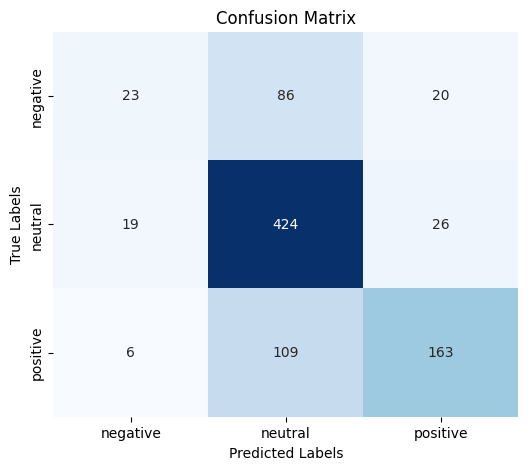

In [ ]:
#Logistics Regression model with TF-IDF and Hyperparameters Tuning
# Define hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1'],  # L2 is default; L1 requires 'liblinear' solver
    'solver': ['liblinear']  # Default solver; change to 'liblinear' for L1
}

# Initialize GridSearch
grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='accuracy')

# Fit the model with grid search
grid_search.fit(X_train_tfidf, y_train)

# Get all hyperparameter combinations tried during the grid search
all_params = grid_search.cv_results_['params']
all_scores = grid_search.cv_results_['mean_test_score']

# Display the list of hyperparameter combinations and their scores
print("\nHyperparameter Combinations and Scores:")
for i, (params, score) in enumerate(zip(all_params, all_scores)):
    print(f"Combination {i+1}: {params} => Accuracy: {score:.4f}")

# Best parameters and score
print("\nBest Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

# Predict on validation set using the best model
best_model = grid_search.best_estimator_
y_val_pred = best_model.predict(X_val_tfidf)

# Classification report
print("\nClassification Report:\n", classification_report(y_val, y_val_pred))

#Define the label names
label_names = ['negative', 'neutral', 'positive']

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)

# Plotting the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# **BERT**


Hyperparameter Combinations and Scores:
Combination 1: {'C': 0.01, 'penalty': 'l1', 'solver': 'liblinear'} => Accuracy: 0.5358
Combination 2: {'C': 0.1, 'penalty': 'l1', 'solver': 'liblinear'} => Accuracy: 0.5488
Combination 3: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'} => Accuracy: 0.6698
Combination 4: {'C': 10, 'penalty': 'l1', 'solver': 'liblinear'} => Accuracy: 0.6637
Combination 5: {'C': 100, 'penalty': 'l1', 'solver': 'liblinear'} => Accuracy: 0.6385

Best Parameters: {'C': 1, 'penalty': 'l1', 'solver': 'liblinear'}
Best CV Score: 0.6698485424341544

Classification Report:
               precision    recall  f1-score   support

    negative       0.49      0.36      0.42       129
     neutral       0.72      0.85      0.78       469
    positive       0.69      0.56      0.62       278

    accuracy                           0.69       876
   macro avg       0.64      0.59      0.61       876
weighted avg       0.68      0.69      0.68       876



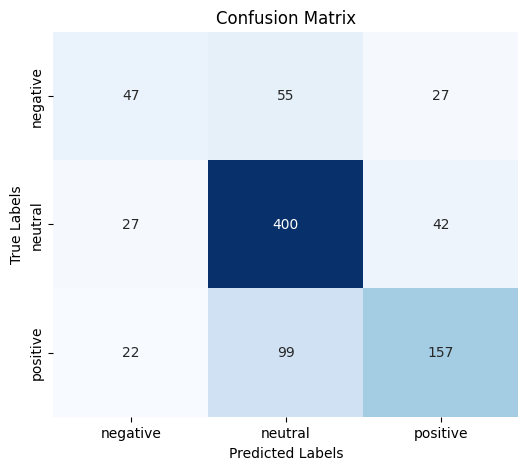

In [ ]:
#Logistics Regression model with BERT and Hyperparameters Tuning
# Define hyperparameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l1'],  # L2 is default; L1 requires 'liblinear' solver
    'solver': ['liblinear']  # Default solver; change to 'liblinear' for L1
}

# Initialize GridSearch
grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_grid, cv=5, scoring='accuracy')

# Fit the model with grid search
grid_search.fit(X_train_bert, y_train)

# Get all hyperparameter combinations tried during the grid search
all_params = grid_search.cv_results_['params']
all_scores = grid_search.cv_results_['mean_test_score']

# Display the list of hyperparameter combinations and their scores
print("\nHyperparameter Combinations and Scores:")
for i, (params, score) in enumerate(zip(all_params, all_scores)):
    print(f"Combination {i+1}: {params} => Accuracy: {score:.4f}")

# Best parameters and score
print("\nBest Parameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

# Predict on validation set using the best model
best_model = grid_search.best_estimator_
y_val_pred = best_model.predict(X_val_bert)

# Classification report
print("\nClassification Report:\n", classification_report(y_val, y_val_pred))

#Define the label names
label_names = ['negative', 'neutral', 'positive']

# Confusion Matrix
cm = confusion_matrix(y_val, y_val_pred)

# Plotting the confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, xticklabels=label_names, yticklabels=label_names)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

## **SUPPORT VECTOR MACHINE (SVM)**

Test Accuracy: 0.6727
Classification report for SVM:
              precision    recall  f1-score   support

    negative       0.46      0.17      0.25       129
     neutral       0.68      0.87      0.76       470
    positive       0.71      0.57      0.63       278

    accuracy                           0.67       877
   macro avg       0.62      0.54      0.55       877
weighted avg       0.66      0.67      0.64       877



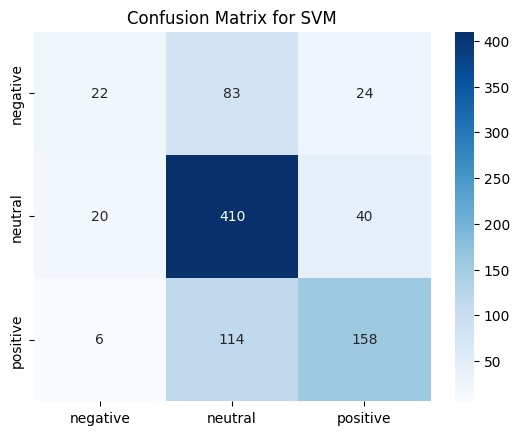

In [ ]:
#Support Vector Machine model with TF-IDF and No-Hyperparameters Tuning
# Train SVM model
svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X_train_tfidf, y_train)

# Predict on the test set
y_test_pred = svm_model.predict(X_test_tfidf)

# Evaluate test performance
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predict and evaluate
y_pred_svm = svm_model.predict(X_test_tfidf)
print("Classification report for SVM:")
print(classification_report(y_test, y_pred_svm))



#Define the label names
label_names = ['negative', 'neutral', 'positive']

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix for SVM')
plt.show()

Parameters: {'C': 0.1, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}, Accuracy: 0.5681
Parameters: {'C': 0.1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}, Accuracy: 0.5363
Parameters: {'C': 0.1, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}, Accuracy: 0.5380
Parameters: {'C': 0.1, 'degree': 2, 'gamma': 'auto', 'kernel': 'linear'}, Accuracy: 0.5681
Parameters: {'C': 0.1, 'degree': 2, 'gamma': 'auto', 'kernel': 'rbf'}, Accuracy: 0.5358
Parameters: {'C': 0.1, 'degree': 2, 'gamma': 'auto', 'kernel': 'poly'}, Accuracy: 0.5358
Parameters: {'C': 0.1, 'degree': 3, 'gamma': 'scale', 'kernel': 'linear'}, Accuracy: 0.5681
Parameters: {'C': 0.1, 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf'}, Accuracy: 0.5363
Parameters: {'C': 0.1, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}, Accuracy: 0.5361
Parameters: {'C': 0.1, 'degree': 3, 'gamma': 'auto', 'kernel': 'linear'}, Accuracy: 0.5681
Parameters: {'C': 0.1, 'degree': 3, 'gamma': 'auto', 'kernel': 'rbf'}, Accuracy: 0.5358
Parameters:

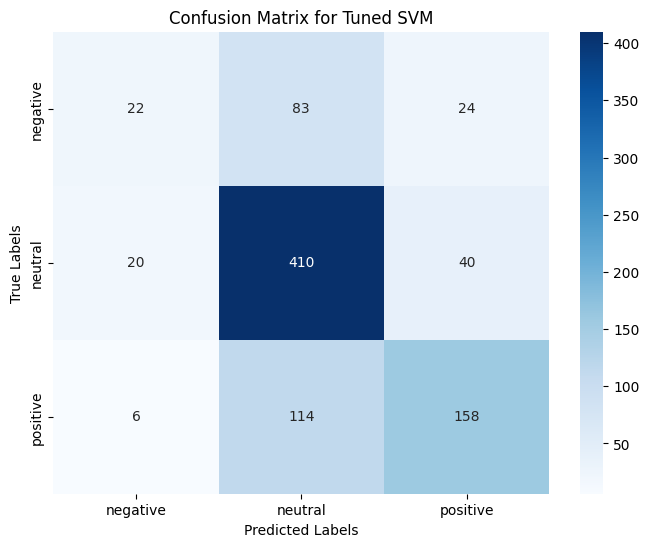

In [ ]:
#Support Vector Machine model with TF-IDF and Hyperparameters Tuning
# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4]  # Only relevant for 'poly' kernel
}

# Initialize the SVM model
svm = SVC()

# Initialize GridSearchCV
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit to training data
grid_search.fit(X_train_tfidf, y_train)

# Extract all results from GridSearchCV
results = grid_search.cv_results_

# Iterate through all combinations and print parameters with their mean test score
for mean_score, params in zip(results['mean_test_score'], results['params']):
    print(f"Parameters: {params}, Accuracy: {mean_score:.4f}")

# Get the best parameters
print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

# Predict and evaluate
y_pred_best_svm = grid_search.predict(X_test_tfidf)
print("Classification report for Tuned SVM:")
print(classification_report(y_test, y_pred_best_svm))

# Define the label names
label_names = ['negative', 'neutral', 'positive']

# Compute the confusion matrix
cm_best_svm = confusion_matrix(y_test, y_pred_best_svm)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best_svm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix for Tuned SVM')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

Test Accuracy: 0.6727
Classification report for SVM:
              precision    recall  f1-score   support

    negative       0.48      0.27      0.35       129
     neutral       0.70      0.86      0.77       470
    positive       0.67      0.54      0.60       278

    accuracy                           0.67       877
   macro avg       0.62      0.56      0.57       877
weighted avg       0.66      0.67      0.65       877



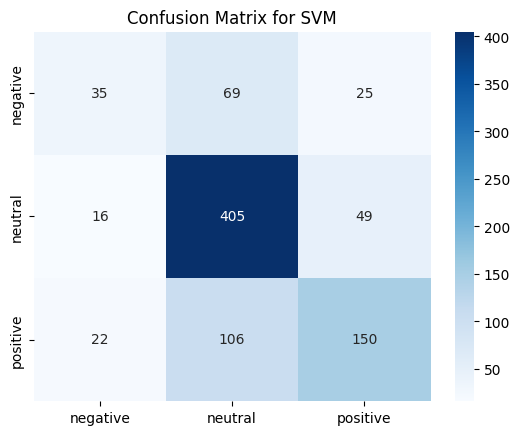

In [ ]:
#Support Vector Machine model with BERT and No-Hyperparameters Tuning
# Train SVM model
svm_model = SVC(kernel='linear', C=1.0)
svm_model.fit(X_train_bert, y_train)

# Predict on the test set
y_test_pred = svm_model.predict(X_test_bert)

# Evaluate test performance
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predict and evaluate
y_pred_svm = svm_model.predict(X_test_bert)
print("Classification report for SVM:")
print(classification_report(y_test, y_pred_svm))

#Define the label names
label_names = ['negative', 'neutral', 'positive']

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix for SVM')
plt.show()

Parameters: {'C': 0.1, 'degree': 2, 'gamma': 'scale', 'kernel': 'linear'}, Accuracy: 0.6447
Parameters: {'C': 0.1, 'degree': 2, 'gamma': 'scale', 'kernel': 'rbf'}, Accuracy: 0.5794
Parameters: {'C': 0.1, 'degree': 2, 'gamma': 'scale', 'kernel': 'poly'}, Accuracy: 0.5786
Parameters: {'C': 0.1, 'degree': 2, 'gamma': 'auto', 'kernel': 'linear'}, Accuracy: 0.6447
Parameters: {'C': 0.1, 'degree': 2, 'gamma': 'auto', 'kernel': 'rbf'}, Accuracy: 0.5358
Parameters: {'C': 0.1, 'degree': 2, 'gamma': 'auto', 'kernel': 'poly'}, Accuracy: 0.5358
Parameters: {'C': 0.1, 'degree': 3, 'gamma': 'scale', 'kernel': 'linear'}, Accuracy: 0.6447
Parameters: {'C': 0.1, 'degree': 3, 'gamma': 'scale', 'kernel': 'rbf'}, Accuracy: 0.5794
Parameters: {'C': 0.1, 'degree': 3, 'gamma': 'scale', 'kernel': 'poly'}, Accuracy: 0.5368
Parameters: {'C': 0.1, 'degree': 3, 'gamma': 'auto', 'kernel': 'linear'}, Accuracy: 0.6447
Parameters: {'C': 0.1, 'degree': 3, 'gamma': 'auto', 'kernel': 'rbf'}, Accuracy: 0.5358
Parameters:

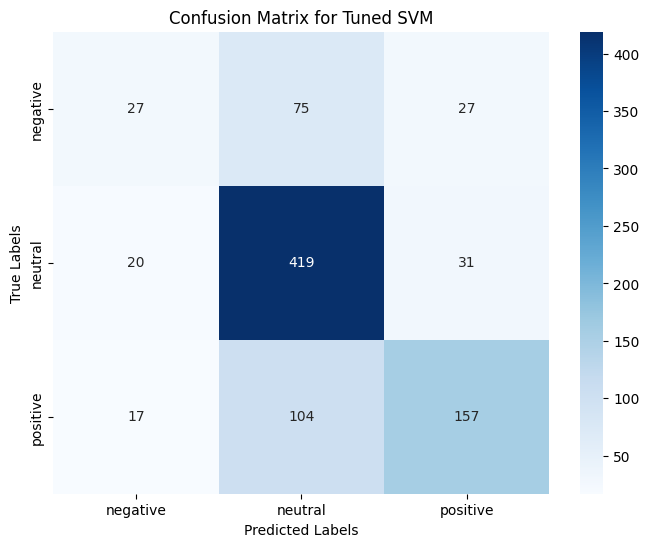

In [ ]:
#Support Vector Machine model with BERT and Hyperparameters Tuning
# Define the parameter grid
param_grid = {
    'C': [0.1, 1, 10],
    'kernel': ['linear', 'rbf', 'poly'],
    'gamma': ['scale', 'auto'],
    'degree': [2, 3, 4]  # Only relevant for 'poly' kernel
}

# Initialize the SVM model
svm = SVC()

# Initialize GridSearchCV
grid_search = GridSearchCV(svm, param_grid, cv=5, scoring='accuracy', n_jobs=-1)

# Fit to training data
grid_search.fit(X_train_bert, y_train)

# Extract all results from GridSearchCV
results = grid_search.cv_results_

# Iterate through all combinations and print parameters with their mean test score
for mean_score, params in zip(results['mean_test_score'], results['params']):
    print(f"Parameters: {params}, Accuracy: {mean_score:.4f}")

# Get the best parameters
print("Best Hyperparameters:", grid_search.best_params_)
print("Best CV Score:", grid_search.best_score_)

# Predict and evaluate
y_pred_best_svm = grid_search.predict(X_test_bert)
print("Classification report for Tuned SVM:")
print(classification_report(y_test, y_pred_best_svm))

# Define the label names
label_names = ['negative', 'neutral', 'positive']

# Compute the confusion matrix
cm_best_svm = confusion_matrix(y_test, y_pred_best_svm)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm_best_svm, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix for Tuned SVM')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

## **NAIVE BAYES**

Test Accuracy: 0.6340
Classification report for Naive Bayes:
              precision    recall  f1-score   support

    negative       1.00      0.02      0.05       129
     neutral       0.62      0.99      0.76       470
    positive       0.73      0.32      0.45       278

    accuracy                           0.63       877
   macro avg       0.78      0.44      0.42       877
weighted avg       0.71      0.63      0.56       877



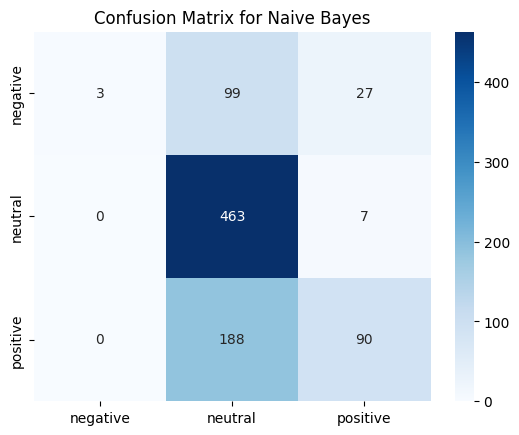

In [ ]:
#Naives Bayes model with TF-IDF and No-Hyperparameters Tuning
# Train Naive Bayes model (Alpha = 2.0)
nb_model = MultinomialNB(alpha=2.0)
nb_model.fit(X_train_tfidf, y_train)

# Predict on the test set
y_test_pred = nb_model.predict(X_test_tfidf)

# Evaluate test performance
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predict and evaluate
y_pred_nb = nb_model.predict(X_test_tfidf)
print("Classification report for Naive Bayes:")
print(classification_report(y_test, y_pred_nb))

#Define the label names
label_names = ['negative', 'neutral', 'positive']

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix for Naive Bayes')
plt.show()


Test Accuracy: 0.6294
Classification report for Naive Bayes:
              precision    recall  f1-score   support

    negative       0.41      0.26      0.32       129
     neutral       0.66      0.87      0.75       470
    positive       0.61      0.40      0.48       278

    accuracy                           0.63       877
   macro avg       0.56      0.51      0.52       877
weighted avg       0.61      0.63      0.60       877



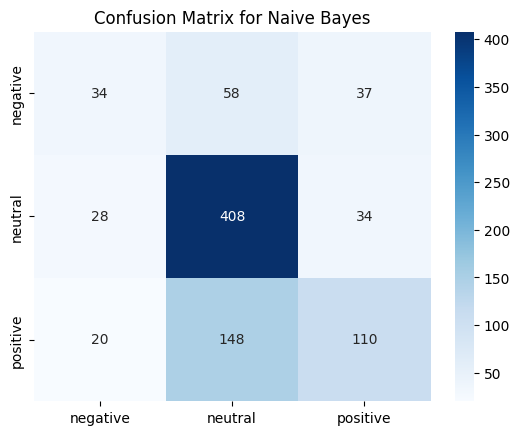

In [ ]:
#Naives Bayes model with BERT and No-Hyperparameters Tuning
# Initialize the scaler to transform data to the range [0, 1]
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform it
X_train_bert_scaled = scaler.fit_transform(X_train_bert)

# Transform the test data using the fitted scaler
X_test_bert_scaled = scaler.transform(X_test_bert)

# Train Naive Bayes model (Alpha = 2.0)
nb_model = MultinomialNB(alpha=2.0)
nb_model.fit(X_train_bert_scaled, y_train)  # Use scaled training data

# Predict on the test set using scaled test data
y_test_pred = nb_model.predict(X_test_bert_scaled)

# Evaluate test performance
test_accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predict and evaluate using scaled test data
y_pred_nb = nb_model.predict(X_test_bert_scaled)
print("Classification report for Naive Bayes:")
print(classification_report(y_test, y_pred_nb))

#Define the label names
label_names = ['negative', 'neutral', 'positive']

# Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)
sns.heatmap(cm_nb, annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
plt.title('Confusion Matrix for Naive Bayes')
plt.show()


# Implementation of Deep Learning(LSTM, GRU)

## **LONG SHORT TERM MEMORY (LSTM)**

In [ ]:
# Converting labels to numerical format
label_encoder = LabelEncoder()
y_train_encoded = label_encoder.fit_transform(y_train)
y_val_encoded = label_encoder.transform(y_val)
y_test_encoded = label_encoder.transform(y_test)

# Convert to one-hot encoding
y_train_onehot = to_categorical(y_train_encoded)
y_val_onehot = to_categorical(y_val_encoded)
y_test_onehot = to_categorical(y_test_encoded)

In [ ]:
# Build the LSTM model
model = Sequential([
    LSTM(128, return_sequences=True, input_shape=(X_train_bert.shape[1], 1)),
    Dropout(0.3),
    LSTM(64),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(y_train_onehot.shape[1], activation='softmax')  # Output layer based on number of classes
])

# Compile the model
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                          │ (None, 512, 128)            │          66,560 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 512, 128)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_1 (LSTM)                        │ (None, 64)                  │          49,408 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 3)                   │              99 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 118,147 (461.51 KB)

 Trainable params: 118,147 (461.51 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_bert, y_train_onehot,
    validation_data=(X_val_bert, y_val_onehot),
    epochs=20,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 163s 1s/step - accuracy: 0.5137 - loss: 1.0116 - val_accuracy: 0.5354 - val_loss: 0.9818
Epoch 2/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 176s 1s/step - accuracy: 0.5375 - loss: 0.9864 - val_accuracy: 0.5354 - val_loss: 0.9855
Epoch 3/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 131s 959ms/step - accuracy: 0.5502 - loss: 0.9740 - val_accuracy: 0.5354 - val_loss: 0.9794
Epoch 4/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 153s 1s/step - accuracy: 0.5350 - loss: 0.9800 - val_accuracy: 0.5354 - val_loss: 0.9747
Epoch 5/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 124s 968ms/step - accuracy: 0.5433 - loss: 0.9673 - val_accuracy: 0.5354 - val_loss: 0.9738
Epoch 6/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 141s 964ms/step - accuracy: 0.5442 - loss: 0.9639 - val_accuracy: 0.5342 - val_loss: 0.9718
Epoch 7/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 142s 963ms/step - accuracy: 0.5366 - loss: 0.9719 - val_accuracy: 0.5400 - val_loss: 0.9666
Epoch 8/20
128/128 ━━━━━━━━━━━━━━━━━━━━ 126s 985ms/step - accuracy: 0.5462 - loss: 0.

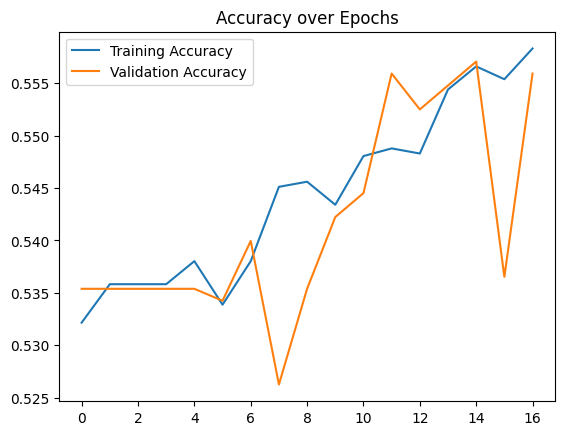

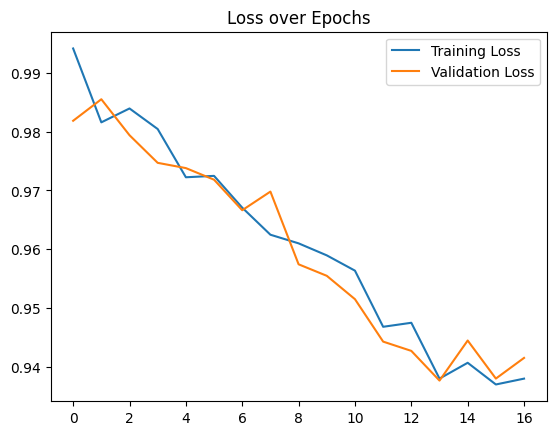

In [ ]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()


28/28 ━━━━━━━━━━━━━━━━━━━━ 12s 439ms/step - accuracy: 0.5363 - loss: 0.9426
Test Accuracy: 0.5496
28/28 ━━━━━━━━━━━━━━━━━━━━ 8s 288ms/step
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       129
     neutral       0.55      0.97      0.71       470
    positive       0.47      0.09      0.15       278

    accuracy                           0.55       877
   macro avg       0.34      0.35      0.29       877
weighted avg       0.45      0.55      0.43       877



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


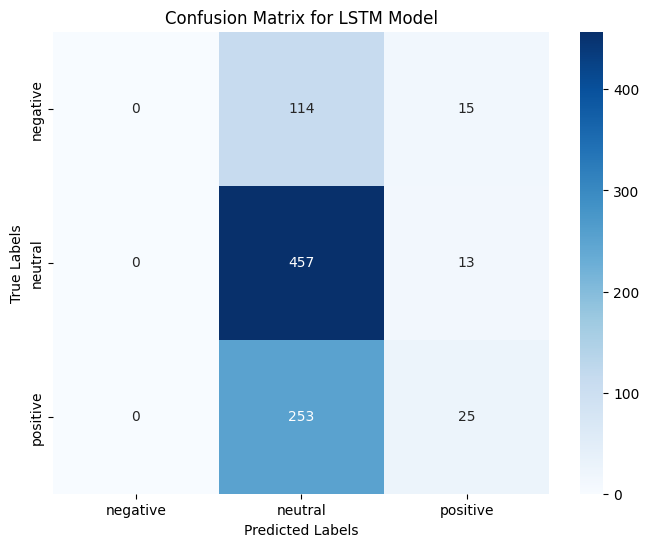

In [ ]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(X_test_bert, y_test_onehot)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predict classes
y_pred = model.predict(X_test_bert)
y_pred_classes = np.argmax(y_pred, axis=1)

# Decode predicted and true labels
y_true_classes = np.argmax(y_test_onehot, axis=1)

# Classification report
print(classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_))

# Compute the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for LSTM Model')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()


In [ ]:
# Define the model with Bidirectional GRU
model = Sequential([
    Bidirectional(GRU(128, return_sequences=False), input_shape=(X_train_bert.shape[1], 1)),
    Dropout(0.5),
    Dense(64, activation='relu', kernel_regularizer=l2(0.01), activity_regularizer=l1(0.01)),
    Dense(3, activation='softmax')  # number of sentiment categories
])

# Compile the model with a custom learning rate
model.compile(loss='categorical_crossentropy', optimizer=Adam(learning_rate=0.01), metrics=['accuracy'])

# Model Summary
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional_1 (Bidirectional)      │ (None, 256)                 │         100,608 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_16 (Dense)                     │ (None, 64)                  │          16,448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 3)                   │             195 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 117,251 (458.01 KB)

 Trainable params: 117,251 (458.01 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train_bert, y_train_onehot,
    validation_data=(X_val_bert, y_val_onehot),
    epochs=15,
    batch_size=32,
    callbacks=[early_stop]
)


Epoch 1/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.5192 - loss: 1.1844 - val_accuracy: 0.5354 - val_loss: 0.9810
Epoch 2/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 129s 1s/step - accuracy: 0.5369 - loss: 0.9820 - val_accuracy: 0.5354 - val_loss: 0.9813
Epoch 3/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 147s 1s/step - accuracy: 0.5315 - loss: 0.9798 - val_accuracy: 0.5354 - val_loss: 0.9810
Epoch 4/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 142s 1s/step - accuracy: 0.5336 - loss: 0.9830 - val_accuracy: 0.5354 - val_loss: 0.9808
Epoch 5/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.5342 - loss: 0.9823 - val_accuracy: 0.5354 - val_loss: 0.9809
Epoch 6/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 150s 1s/step - accuracy: 0.5404 - loss: 0.9737 - val_accuracy: 0.5354 - val_loss: 0.9811
Epoch 7/15
128/128 ━━━━━━━━━━━━━━━━━━━━ 135s 1s/step - accuracy: 0.5387 - loss: 0.9814 - val_accuracy: 0.5354 - val_loss: 0.9809


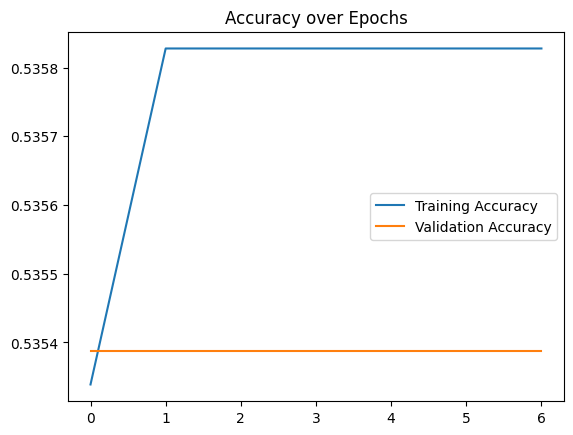

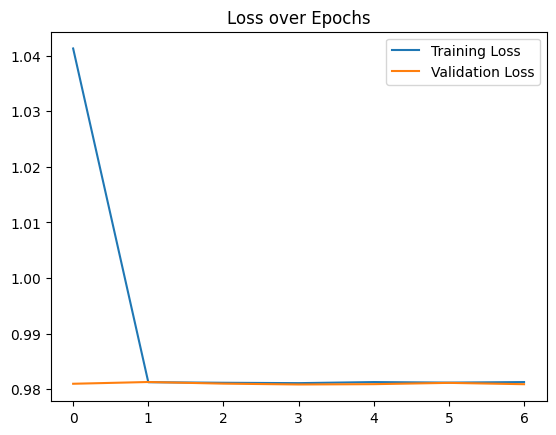

In [ ]:
# Plot accuracy
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')
plt.show()

# Plot loss
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss over Epochs')
plt.show()


28/28 ━━━━━━━━━━━━━━━━━━━━ 6s 211ms/step - accuracy: 0.5209 - loss: 0.9928
Test Accuracy: 0.5359
28/28 ━━━━━━━━━━━━━━━━━━━━ 5s 176ms/step


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


              precision    recall  f1-score   support

    negative       0.00      0.00      0.00       129
     neutral       0.54      1.00      0.70       470
    positive       0.00      0.00      0.00       278

    accuracy                           0.54       877
   macro avg       0.18      0.33      0.23       877
weighted avg       0.29      0.54      0.37       877



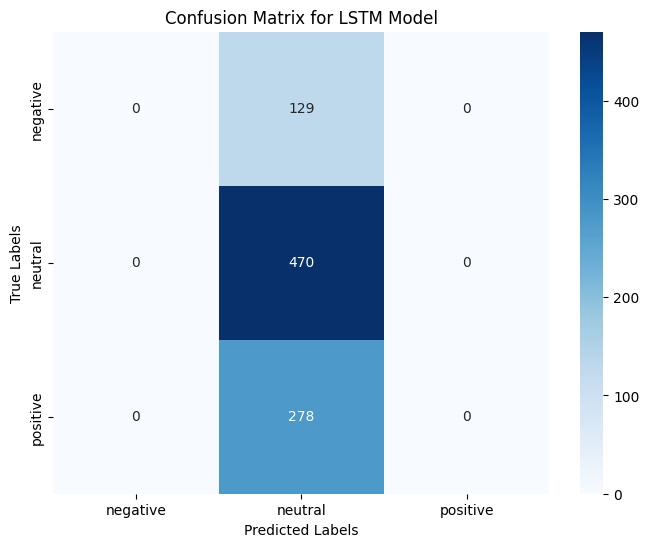

In [ ]:
# Evaluate on test data
test_loss, test_accuracy = model.evaluate(X_test_bert, y_test_onehot)
print(f"Test Accuracy: {test_accuracy:.4f}")

# Predict classes
y_pred = model.predict(X_test_bert)
y_pred_classes = np.argmax(y_pred, axis=1)

# Decode predicted and true labels
y_true_classes = np.argmax(y_test_onehot, axis=1)

# Classification report
print(classification_report(y_true_classes, y_pred_classes, target_names=label_encoder.classes_))

# Compute the confusion matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.title('Confusion Matrix for LSTM Model')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()
